# PyClone

Dependencies this section
- See [PyClone respiratory](https://github.com/Roth-Lab/pyclone/blob/master/conda/recipe/meta.yaml)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from sklearn.metrics import adjusted_rand_score
import xlrd

from collections import Counter
import itertools

In [2]:
def returndata(name):
    fo = xlrd.open_workbook(name)
    sheet = fo.sheet_by_index(0)
    for i in range(len(sheet.col_values(0))):
        if i == 0:
            continue
        else:
            if sheet.row_values(i)[11] in ['missense SNV','stopgain','stoploss']:
                id = str(sheet.row_values(i)[0]) + ':' + str(int(sheet.row_values(i)[1]))

                format = sheet.row_values(i)[18]
                format = format.split(':')
                r_v = format[1].split(',')

                if format[0] == '0/1':
                    minor = '1'
                    major = '1'
                else:
                    minor = '0'
                    major = '2'           
                col = [id,r_v[0],r_v[1],'2',minor,major]
                data.append(col)
    return data

In [3]:
data = [['mutation_id','ref_counts','var_counts','normal_cn','minor_cn','major_cn']]
data = returndata('data/raw/h3_1.samtools.snp.annovar.mm10_multianno.xls')

f = open('data/intermediate/1_h.tsv', 'w')
for item in data:
    f.write('\t'.join(item) + '\n') 
f.close()

In [4]:
data = [['mutation_id','ref_counts','var_counts','normal_cn','minor_cn','major_cn']]
data = returndata('data/raw/ad_29.samtools.snp.annovar.mm10_multianno.xls')

f = open('data/intermediate/2_ad.tsv', 'w')
for item in data:
    f.write('\t'.join(item) + '\n') 
f.close()

In [5]:
data = [['mutation_id','ref_counts','var_counts','normal_cn','minor_cn','major_cn']]
data = returndata('data/raw/ec_191.samtools.snp.annovar.mm10_multianno.xls')

f = open('data/intermediate/3_ec.tsv', 'w')
for item in data:
    f.write('\t'.join(item) + '\n') 
f.close()

In [6]:
data = [['mutation_id','ref_counts','var_counts','normal_cn','minor_cn','major_cn']]
data = returndata('data/raw/lc_182.samtools.snp.annovar.mm10_multianno.xls')

f = open('data/intermediate/4_lc.tsv', 'w')
for item in data:
    f.write('\t'.join(item) + '\n') 
f.close()

In [ ]:
%%bash
export MPLBACKEND=Agg
PyClone run_analysis_pipeline --in_files data/intermediate/1_h.tsv data/intermediate/2_ad.tsv data/intermediate/3_ec.tsv data/intermediate/4_lc.tsv --working_dir results/pyclone_analysis

## robustness

In [7]:
def load_cnv(gff):
    segs = []
    for line in open(gff):
        f = line.rstrip('\n').split('\t')
        if len(f) < 9:
            continue
        attr = dict(kv.split('=') for kv in f[8].split(';') if '=' in kv)
        segs.append([f[0], int(f[3]), int(f[4]), int(attr['CopyNumber'])])
    return segs

def get_cn(segs, chrom, pos):
    for c, start, end, cn in segs:
        if c == chrom and start <= pos <= end:
            return cn
    return 2

In [8]:
mapping = {
    'data/intermediate/1_h.tsv': 'data/raw/Gff/h3_1.freec.somatic.cnv.gff',
    'data/intermediate/2_ad.tsv': 'data/raw/Gff/ad_29.freec.somatic.cnv.gff',
    'data/intermediate/3_ec.tsv': 'data/raw/Gff/ec_191.freec.somatic.cnv.gff',
    'data/intermediate/4_lc.tsv': 'data/raw/Gff/lc_182.freec.somatic.cnv.gff',
}

for tsv, gff in mapping.items():
    segs = load_cnv(gff)
    out, n_cn0, n_kept = [], 0, 0
    
    for line in open(tsv):
        col = line.rstrip('\n').split('\t')
        
        if col[0] == 'mutation_id':
            out.append(col)
            continue
            
        chrom, pos = col[0].split(':')
        cn = get_cn(segs, chrom, int(pos))
        if cn == 0:
            n_cn0 += 1
            continue
        col[4] = '0'
        col[5] = str(cn)
        out.append(col)
        n_kept += 1
    outname = tsv.replace('.tsv', '_versionB.tsv')
    with open(outname, 'w') as f:
        for col in out:
            f.write('\t'.join(col) + '\n')
    print(n_cn0, n_kept)

0 2290
1303 1680
1029 2237
995 1446


In [ ]:
%%bash
export MPLBACKEND=Agg
PyClone run_analysis_pipeline --in_files data/intermediate/1_h_versionB.tsv data/intermediate/2_ad_versionB.tsv data/intermediate/3_ec_versionB.tsv data/intermediate/4_lc_versionB.tsv --working_dir results/robust

In [9]:
la = pd.read_csv(f'results/pyclone_analysis/tables/loci.tsv', sep='\t')
la

,mutation_id,sample_id,cluster_id,cellular_prevalence,cellular_prevalence_std,variant_allele_frequency
0,chr10:100087361,4_lc,0,0.001258,0.010078,0.0
1,chr10:100087361,3_ec,0,0.000639,0.004961,0.0
2,chr10:100087361,2_ad,0,0.000485,0.005874,0.0
3,chr10:100087361,1_h,0,0.001339,0.010954,0.0
4,chr10:100341470,4_lc,0,0.001183,0.007349,0.0
...,...,...,...,...,...,...
2707,chr8:26160882,1_h,0,0.001217,0.005199,0.0
2708,chrX:124128539,4_lc,0,0.001154,0.006172,0.0
2709,chrX:124128539,3_ec,0,0.000655,0.006107,0.0
2710,chrX:124128539,2_ad,0,0.000452,0.005377,0.0


In [10]:
lb = pd.read_csv(f'results/robust/tables/loci.tsv', sep='\t')
lb['sample_id'] = lb['sample_id'].str.replace('_versionB', '')
lb

,mutation_id,sample_id,cluster_id,cellular_prevalence,cellular_prevalence_std,variant_allele_frequency
0,chr10:127003427,2_ad,2,0.001062,0.007443,0.0
1,chr10:127003427,4_lc,2,0.001761,0.003173,0.0
2,chr10:127003427,1_h,2,0.001620,0.006187,0.0
3,chr10:127003427,3_ec,2,0.503432,0.035900,0.5
4,chr10:127033026,2_ad,2,0.001048,0.006230,0.0
...,...,...,...,...,...,...
743,chr7:79695130,3_ec,0,0.000645,0.009846,0.0
744,chr8:102674037,2_ad,0,0.000899,0.007360,0.0
745,chr8:102674037,4_lc,0,0.000648,0.005797,0.0
746,chr8:102674037,1_h,0,0.000846,0.005884,0.0


### number of clusters

In [11]:
la['cluster_id'].nunique(), lb['cluster_id'].nunique()

(6, 6)

### ARI

In [12]:
ca = la[['mutation_id','cluster_id']].drop_duplicates('mutation_id')
ca

,mutation_id,cluster_id
0,chr10:100087361,0
4,chr10:100341470,0
8,chr10:100447185,0
12,chr10:100451428,0
16,chr10:100488594,0
...,...,...
2692,chr7:79695003,0
2696,chr7:79695130,0
2700,chr8:102674037,0
2704,chr8:26160882,0


In [13]:
cb = lb[['mutation_id','cluster_id']].drop_duplicates('mutation_id')
cb

,mutation_id,cluster_id
0,chr10:127003427,2
4,chr10:127033026,2
8,chr10:127080762,2
12,chr10:127174816,2
16,chr10:127175011,2
...,...,...
728,chr7:79694655,0
732,chr7:79694677,0
736,chr7:79695003,0
740,chr7:79695130,0


In [14]:
merged  = ca.merge(cb, on='mutation_id', suffixes=('_A','_B'))
merged

,mutation_id,cluster_id_A,cluster_id_B
0,chr10:127003427,3,2
1,chr10:127033026,3,2
2,chr10:127080762,3,2
3,chr10:127174816,3,2
4,chr10:127175011,3,2
...,...,...,...
182,chr7:79694655,0,0
183,chr7:79694677,0,0
184,chr7:79695003,0,0
185,chr7:79695130,0,0


In [15]:
merged.shape

(187, 3)

In [16]:
cn = {k: pd.read_csv(k.replace('.tsv', '_versionB.tsv'), sep='\t')
          .set_index('mutation_id')
          .eval('minor_cn + major_cn')
      for k in mapping}

states = {mut: [cn[k][mut] for k in mapping]
          for mut in sorted(merged['mutation_id'].unique())}

sum(any(c != 2 for c in v) for v in states.values())

63

In [17]:
dict(sorted(Counter(c for v in states.values() for c in v).items()))

{np.int64(1): 79, np.int64(2): 669}

only 1 and 2

In [18]:
adjusted_rand_score(merged['cluster_id_A'], merged['cluster_id_B'])

1.0

### CCF correlation

In [19]:
la

,mutation_id,sample_id,cluster_id,cellular_prevalence,cellular_prevalence_std,variant_allele_frequency
0,chr10:100087361,4_lc,0,0.001258,0.010078,0.0
1,chr10:100087361,3_ec,0,0.000639,0.004961,0.0
2,chr10:100087361,2_ad,0,0.000485,0.005874,0.0
3,chr10:100087361,1_h,0,0.001339,0.010954,0.0
4,chr10:100341470,4_lc,0,0.001183,0.007349,0.0
...,...,...,...,...,...,...
2707,chr8:26160882,1_h,0,0.001217,0.005199,0.0
2708,chrX:124128539,4_lc,0,0.001154,0.006172,0.0
2709,chrX:124128539,3_ec,0,0.000655,0.006107,0.0
2710,chrX:124128539,2_ad,0,0.000452,0.005377,0.0


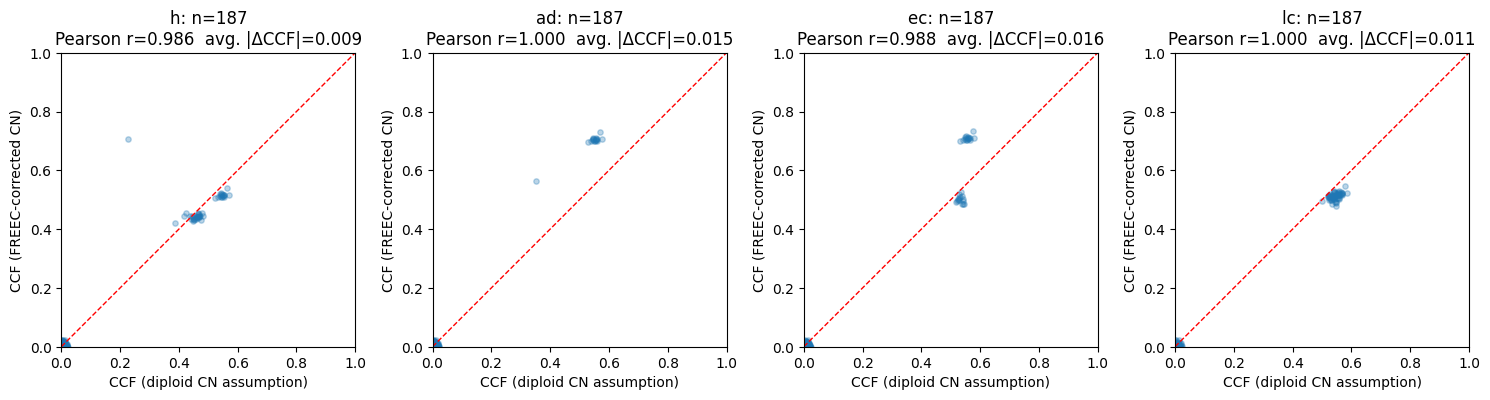

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, s in zip(axes, sorted(la['sample_id'].unique())):
    pa = la[la['sample_id']==s][['mutation_id','cellular_prevalence']]
    pb = lb[lb['sample_id']==s][['mutation_id','cellular_prevalence']]
    mm = pa.merge(pb, on='mutation_id', suffixes=('_A','_B'))

    r,_ = pearsonr(mm['cellular_prevalence_A'], mm['cellular_prevalence_B'])
    mad = (mm['cellular_prevalence_A']-mm['cellular_prevalence_B']).abs().mean()

    np.random.seed(138)
    jit = 0.01
    ax.scatter(mm['cellular_prevalence_A'] + np.random.normal(0,jit,len(mm)),
               mm['cellular_prevalence_B'] + np.random.normal(0,jit,len(mm)),
               s=15, alpha=0.3)
    ax.plot([0,1],[0,1],'r--',lw=1)
    
    ax.set_title(f'{s[2:]}: n={len(mm)}\nPearson r={r:.3f}  avg. |ΔCCF|={mad:.3f}')
    ax.set_xlabel('CCF (diploid CN assumption)')
    ax.set_ylabel('CCF (FREEC-corrected CN)')
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_aspect('equal')  

plt.tight_layout()
plt.savefig('results/figures/ccf_scatter.svg')
plt.show()

### convergence

In [21]:
alpha = pd.read_csv('results/pyclone_analysis/trace/alpha.tsv.bz2', sep='\t')
alpha

,1.0
0,129.817256
1,13.365924
2,4.684982
3,1.729582
4,2.056194
...,...
9994,1.205454
9995,0.817540
9996,1.323092
9997,0.954248


In [22]:
prec  = pd.read_csv('results/pyclone_analysis/trace/precision.tsv.bz2', sep='\t')

clusters = pd.read_csv('results/pyclone_analysis/trace/labels.tsv.bz2', sep='\t')
clusters

,chr1:88242760,chr1:171599888,chr1:85601172,chr10:100488594,chr10:58231344,chr10:86897981,chr16:32755039,chr10:86731086,chr16:32775807,chr10:127742253,...,chr1:88244970,chr16:37997964,chr16:57571404,chr1:173270447,chr16:20683460,chr11:9354911,chr1:179752948,chr11:9298539,chr16:32751142,chr5:93637765
0,0,1,2,3,4,5,6,7,8,9,...,668,669,670,671,672,673,674,675,676,677
1,4,4,4,4,14,4,4,4,9,0,...,4,4,4,4,4,3,8,3,9,4
2,3,3,3,3,1,3,3,3,8,0,...,3,3,3,3,3,2,7,2,8,3
3,3,3,3,3,9,3,5,3,8,0,...,3,3,3,3,3,2,7,2,8,3
4,12,12,11,11,9,12,12,11,8,0,...,12,11,12,12,12,2,7,2,8,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,3,3,3,3,5,3,3,3,2,4,...,3,3,3,3,3,0,1,0,2,3
9996,3,3,3,3,5,3,3,3,2,4,...,3,3,3,3,3,0,1,0,2,3
9997,3,3,3,3,5,3,3,3,2,4,...,3,3,3,3,3,0,1,0,2,3
9998,3,3,3,3,5,3,3,3,2,4,...,3,3,3,3,3,0,1,0,2,3


In [23]:
k_per_iter = clusters.apply(lambda r: r.nunique(), axis=1)
k_per_iter

0       678
1        16
2        11
3        12
4        13
       ... 
9995      6
9996      7
9997      6
9998      6
9999      6
Length: 10000, dtype: int64

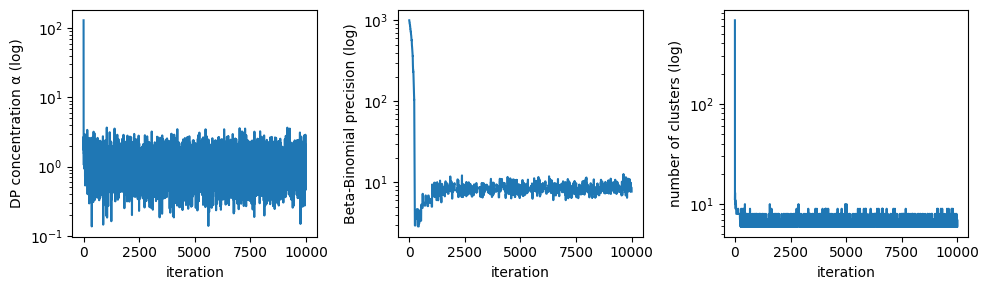

In [24]:
fig, ax = plt.subplots(1, 3, figsize=(10,3))
ax[0].plot(alpha.iloc[:,-1])
ax[0].set_ylabel('DP concentration α (log)')
ax[0].set_xlabel('iteration')
ax[0].set_yscale('log')

ax[1].plot(prec.iloc[:,-1])
ax[1].set_ylabel('Beta-Binomial precision (log)')
ax[1].set_xlabel('iteration')
ax[1].set_yscale('log')

ax[2].plot(k_per_iter)
ax[2].set_xlabel('iteration')
ax[2].set_ylabel('number of clusters (log)')
ax[2].set_yscale('log')

plt.tight_layout()
plt.savefig('results/figures/convergence.svg')
plt.show()

In [25]:
m2c = la.set_index('mutation_id')['cluster_id']
m2c

mutation_id
chr10:100087361    0
chr10:100087361    0
chr10:100087361    0
chr10:100087361    0
chr10:100341470    0
                  ..
chr8:26160882      0
chrX:124128539     0
chrX:124128539     0
chrX:124128539     0
chrX:124128539     0
Name: cluster_id, Length: 2712, dtype: int64

1_h: max |ΔCCF| (burnin 0 vs 1000) = 0.0113
2_ad: max |ΔCCF| (burnin 0 vs 1000) = 0.0059
3_ec: max |ΔCCF| (burnin 0 vs 1000) = 0.0061
4_lc: max |ΔCCF| (burnin 0 vs 1000) = 0.0079


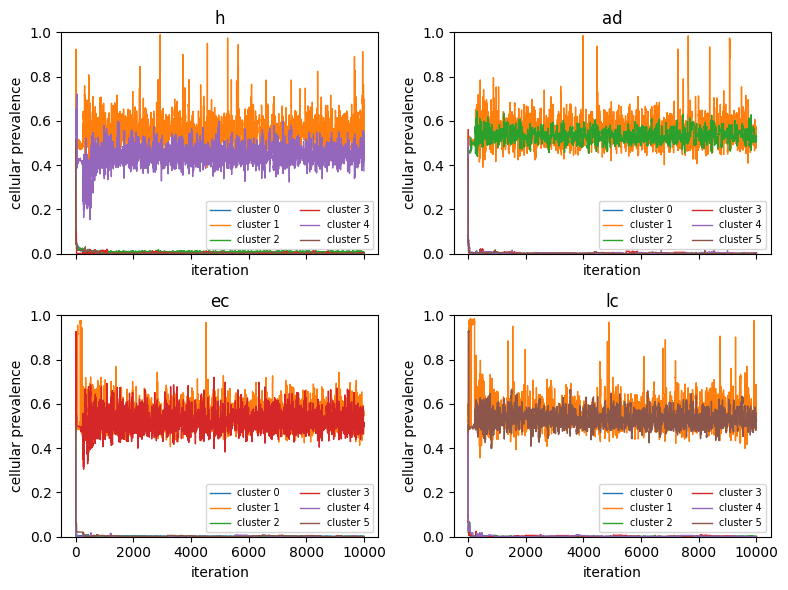

In [26]:
stages = ['1_h','2_ad','3_ec','4_lc']
fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharex=True)

for ax, s in zip(axes.ravel(), stages):
    tr = pd.read_csv(f'results/pyclone_analysis/trace/{s}.cellular_prevalence.tsv.bz2', sep='\t')

    full = tr.mean(axis=0)
    burned = tr.iloc[1000:].mean(axis=0) # exclude first 1000 iterations
    d = (full - burned).abs().max()
    print(f'{s}: max |ΔCCF| (burnin 0 vs 1000) = {d:.4f}')

    clusters = sorted(m2c.unique())
    for c in clusters:
        muts = [m for m in m2c[m2c == c].index if m in tr.columns]
        if not muts:
            continue

        ax.plot(tr[muts].mean(axis=1).values, lw=1.0, label=f'cluster {c}')
    ax.set_title(s[2:])
    ax.set_ylabel('cellular prevalence')
    ax.set_xlabel('iteration')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=7, ncol=2, loc='lower right')

plt.tight_layout()
plt.savefig('results/figures/ccf_trace_bycluster.svg')
plt.show()

### Reproducibility

In [ ]:
%%bash
export MPLBACKEND=Agg
mkdir results/robust/seed138
mkdir results/robust/seed192
mkdir results/robust/seed506
PyClone run_analysis_pipeline --seed 138 --in_files data/intermediate/1_h.tsv data/intermediate/2_ad.tsv data/intermediate/3_ec.tsv data/intermediate/4_lc.tsv --working_dir results/robust/seed138
PyClone run_analysis_pipeline --seed 192 --in_files data/intermediate/1_h.tsv data/intermediate/2_ad.tsv data/intermediate/3_ec.tsv data/intermediate/4_lc.tsv --working_dir results/robust/seed192
PyClone run_analysis_pipeline --seed 506 --in_files data/intermediate/1_h.tsv data/intermediate/2_ad.tsv data/intermediate/3_ec.tsv data/intermediate/4_lc.tsv --working_dir results/robust/seed506

In [27]:
seeds = [138, 192, 506]

labelings = {}
for s in seeds:
    loci = pd.read_csv(f'results/robust/seed{s}/tables/loci.tsv', sep='\t')
    labelings[s] = loci.set_index('mutation_id')['cluster_id']
    print(f'seed{s}: cluster numbers = {labelings[s].nunique()}')

seed138: cluster numbers = 6
seed192: cluster numbers = 6
seed506: cluster numbers = 6


common mutations

In [28]:
common = set.intersection(*[set(v.index) for v in labelings.values()])
common = sorted(common)
len(common)

678

pairwise ARI

In [29]:
for a, b in itertools.combinations(seeds, 2):
    la = labelings[a].loc[common].values
    lb = labelings[b].loc[common].values
    ari = adjusted_rand_score(la, lb)
    print(f'seed{a} vs seed{b}: ARI = {ari:.4f}')

seed138 vs seed192: ARI = 1.0000
seed138 vs seed506: ARI = 1.0000
seed192 vs seed506: ARI = 1.0000


In [30]:
ref = pd.read_csv('results/pyclone_analysis/tables/loci.tsv', sep='\t')
labelings['ref'] = ref.set_index('mutation_id')['cluster_id']

common = set.intersection(*[set(v.index) for v in labelings.values()])
common = sorted(common)

for s in seeds:
    la = labelings['ref'].loc[common].values
    lb = labelings[s].loc[common].values
    ari = adjusted_rand_score(la, lb)
    print(f'ref vs seed{s}: ARI = {ari:.4f}')

ref vs seed138: ARI = 1.0000
ref vs seed192: ARI = 1.0000
ref vs seed506: ARI = 1.0000


## heatmap

Dependencies this section
- R >= 4.0
- pheatmap >= 1.0.13

In [1]:
library(tidyr)

In [2]:
rm(list = ls())
options(stringsAsFactors = F)
loci = read.table("results/pyclone_analysis/tables/loci.tsv",header = T)
head(loci)

,mutation_id,sample_id,cluster_id,cellular_prevalence,cellular_prevalence_std,variant_allele_frequency
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
1,chr10:100087361,4_lc,0,0.0012582913,0.010077934,0
2,chr10:100087361,3_ec,0,0.0006390684,0.004961420,0
3,chr10:100087361,2_ad,0,0.0004854982,0.005874498,0
4,chr10:100087361,1_h,0,0.0013386652,0.010954394,0
5,chr10:100341470,4_lc,0,0.0011830881,0.007348837,0
6,chr10:100341470,3_ec,0,0.0006423789,0.004846664,0


In [3]:
clusters_list <- loci[!duplicated(loci$mutation_id), c(1, 3)]
rownames(clusters_list) = clusters_list[, 1]
cluster_id = data.frame(cluster_id = as.character(clusters_list$cluster_id))
rownames(cluster_id) = clusters_list[, 1]

cellular prevalence

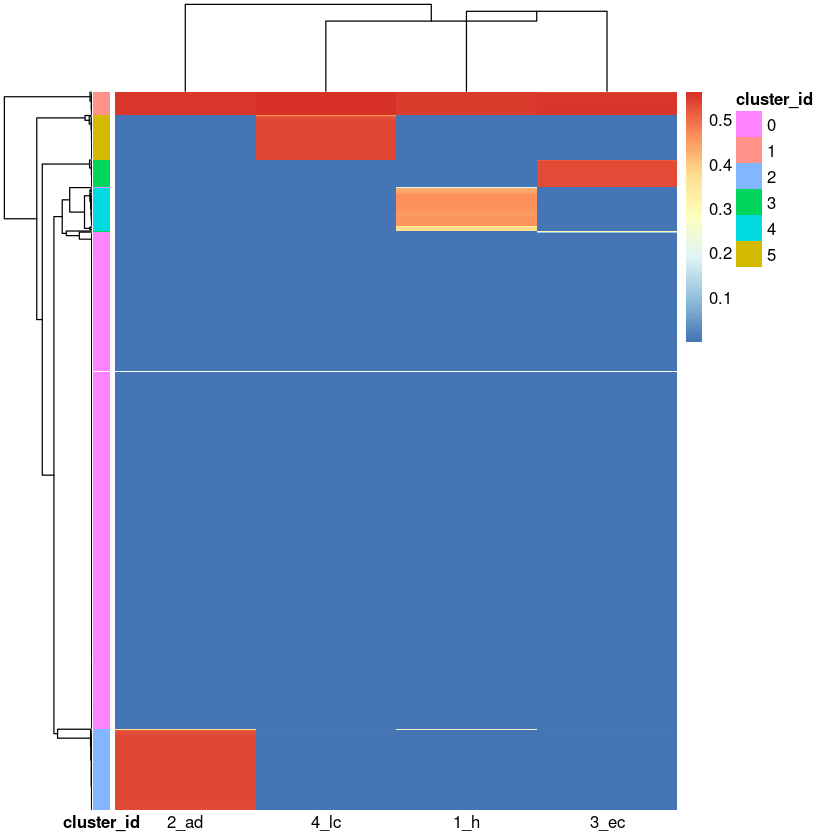

In [4]:
cellular_prevalence = spread(loci[, c(1, 2, 4)], key = sample_id, value = cellular_prevalence)
rownames(cellular_prevalence) = cellular_prevalence[, 1]
cellular_prevalence = cellular_prevalence[,-1]
sampe_id = colnames(cellular_prevalence)
cellular_prevalence = as.data.frame(t(apply(cellular_prevalence, 1, as.numeric)))
colnames(cellular_prevalence) = sampe_id
pheatmap::pheatmap(
  cellular_prevalence,
  annotation_row = cluster_id,
  show_rownames = F,
  clustering_method = 'median',
  angle_col = 0
)

variant allele frequency

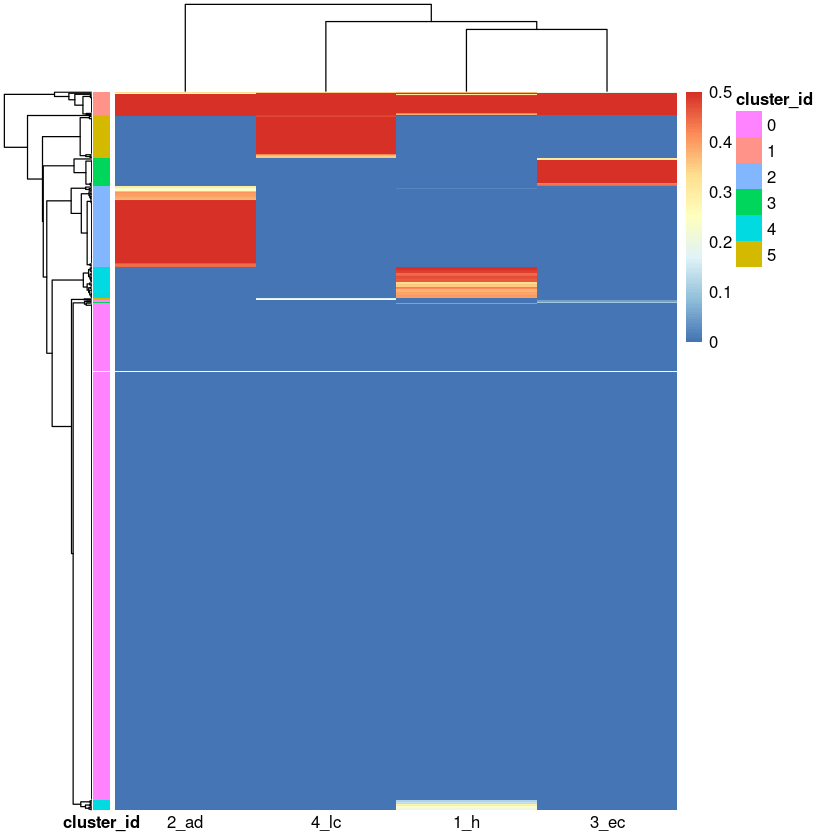

In [5]:
variant_allele_frequency = spread(loci[, c(1, 2, 6)], key = sample_id, value = variant_allele_frequency)
rownames(variant_allele_frequency) = variant_allele_frequency[, 1]
variant_allele_frequency <- variant_allele_frequency[match(clusters_list$mutation_id, rownames(variant_allele_frequency)), ]
variant_allele_frequency = variant_allele_frequency[,-1]
sampe_id = colnames(variant_allele_frequency)
variant_allele_frequency = as.data.frame(t(apply(variant_allele_frequency, 1, as.numeric)))
colnames(variant_allele_frequency) = sampe_id

pheatmap::pheatmap(
  variant_allele_frequency,
  annotation_row = cluster_id,
  show_rownames = F,
  clustering_method = 'average',
  angle_col = 0
)

In [6]:
colnames(variant_allele_frequency) <- gsub("^[0-9]+_", "", colnames(variant_allele_frequency))
variant_allele_frequency <- variant_allele_frequency[, c("h", "ad", "ec", "lc")]

cluster_out <- clusters_list[rownames(variant_allele_frequency), ]

write.table(format(variant_allele_frequency, nsmall = 1), 
            file = "data/intermediate/freq.txt",
            sep = "\t", row.names = F, col.names = F, quote = F)

write.table(cluster_out[, 2], file = "data/intermediate/cluster.txt",
            row.names = F, col.names = F, quote = F)

# CITUP

Dependencies this section
- scikit-learn >= 0.15
- pandas == 0.19.2

In [ ]:
%bash
run_citup_qip.py --submit local data/intermediate/freq.txt data/intermediate/cluster.txt results/citup/results.h5
python citup.py results/citup/results.h5 | sed 's/^ \[//;s/\[//g;s/\]//g' | tr ' ' '\t' | grep -v '\.' > results/citup/tree.txt
python citup.py results.h5 | sed 's/^ \[//;s/\[//g;s/\]//g' | tr ' ' '\t' | grep '\.' > results/citup/cellfreq.txt

# TimeScape

Dependencies this section
- R >= 3.3
- timescape >= 1.30.0

In [1]:
library(tidyr)
library(timescape)

In [2]:
options(stringsAsFactors = F)

In [3]:
tree_edges = read.table(paste0("results/citup/tree.txt"))
colnames(tree_edges) = c("source","target")
tree_edges

source,target
<int>,<int>
0,1
0,2
0,3
0,4
0,5
0,6


In [4]:
cellfreq = read.table(paste0("results/citup/cellfreq.txt"))
colnames(cellfreq) = 0:(length(cellfreq)-1)
cellfreq

Warning message in read.table(paste0("results/citup/cellfreq.txt")):
“incomplete final line found by readTableHeader on 'results/citup/cellfreq.txt'”


0,1,2,3,4,5,6
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.1459470,0.370539,0.000125618,0.000000,0.000000,0.00677461,0.476614
0.0474593,0.000000,0.000000000,0.000000,0.000000,0.47094600,0.481594
0.0430099,0.000000,0.000110051,0.000000,0.471106,0.00000000,0.485774
0.0329185,0.000000,0.000000000,0.473998,0.000000,0.00000000,0.493083


In [5]:
sample_id = read.table(paste0("data/raw/sample_id.txt"))
cellfreq$timepoint = sample_id[ , 1]
cellfreq

0,1,2,3,4,5,6,timepoint
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
0.1459470,0.370539,0.000125618,0.000000,0.000000,0.00677461,0.476614,h
0.0474593,0.000000,0.000000000,0.000000,0.000000,0.47094600,0.481594,ad
0.0430099,0.000000,0.000110051,0.000000,0.471106,0.00000000,0.485774,ec
0.0329185,0.000000,0.000000000,0.473998,0.000000,0.00000000,0.493083,lc


In [6]:
clonal_prev = gather(cellfreq, key="clone_id", value = "clonal_prev", -timepoint)
# clonal_prev = clonal_prev[order(clonal_prev$timepoint),] old, wrong
clonal_prev$timepoint = factor(clonal_prev$timepoint, levels = c("h","ad","ec","lc"))
clonal_prev = clonal_prev[order(clonal_prev$timepoint), ]
clonal_prev

,timepoint,clone_id,clonal_prev
,<fct>,<chr>,<dbl>
1,h,0,0.145947000
5,h,1,0.370539000
9,h,2,0.000125618
13,h,3,0.000000000
17,h,4,0.000000000
21,h,5,0.006774610
25,h,6,0.476614000
2,ad,0,0.047459300
6,ad,1,0.000000000


In [7]:
p = timescape(clonal_prev = clonal_prev, tree_edges = tree_edges, height=260)
p

HTML widgets cannot be represented in plain text (need html)